In [72]:
import pandas as pd
import numpy as np

In [193]:
veri = pd.read_csv("ev_fiyat.csv")
veri.head()

,Ilan no,il,Emlak Tipi,m² (Brüt),m² (Net),Oda Sayısı,Bina Yaşı,Bulunduğu Kat,Kat Sayısı,Isıtma turu,Banyo Sayısı,Balkon sayisi,Asansör,Otopark,Site İçerisinde,Aidat (TL),Krediye Uygun,fiyat
0,1011499,Mersin,Daire,202,149,2,46,6,8,Doğalgaz (Kombi),3,1,True,True,False,0,False,919872
1,1006475,İzmir,Daire,227,163,3,40,3,4,Doğalgaz (Kombi),1,2,True,False,False,22,True,3302065
2,1013167,İstanbul,Arsa,423,423,0,42,3,12,Soba,1,0,False,False,False,0,False,4742538
3,1000862,Antalya,Daire,163,129,2,2,2,14,Doğalgaz (Kombi),3,1,True,True,True,535,False,1258417
4,1005970,Mersin,Daire,78,58,3,62,0,8,Klima,2,1,True,False,False,16,True,433298


In [195]:
veri.loc[veri["fiyat"]==veri["fiyat"].max()]

,Ilan no,il,Emlak Tipi,m² (Brüt),m² (Net),Oda Sayısı,Bina Yaşı,Bulunduğu Kat,Kat Sayısı,Isıtma turu,Banyo Sayısı,Balkon sayisi,Asansör,Otopark,Site İçerisinde,Aidat (TL),Krediye Uygun,fiyat
9086,1009434,İstanbul,Arsa,1779,1779,0,63,1,6,Merkezi,1,0,False,False,False,58,False,43892844


In [197]:
X = veri.drop(["Ilan no","fiyat"],axis=1)
y = veri["fiyat"]

In [199]:
veri.isna().sum()

Ilan no            0
il                 0
Emlak Tipi         0
m² (Brüt)          0
m² (Net)           0
Oda Sayısı         0
Bina Yaşı          0
Bulunduğu Kat      0
Kat Sayısı         0
Isıtma turu        0
Banyo Sayısı       0
Balkon sayisi      0
Asansör            0
Otopark            0
Site İçerisinde    0
Aidat (TL)         0
Krediye Uygun      0
fiyat              0
dtype: int64

In [201]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cols = ["il","Emlak Tipi","Isıtma turu"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer(
    [("one_hot",one_hot,cols)],
    remainder="passthrough"
                 )
transformed_X = transformer.fit_transform(X)

In [203]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)
model = RandomForestRegressor()
model.fit(X_train,y_train);

In [204]:
model.score(X_test, y_test)

0.8651319128512462

In [205]:
y_preds = model.predict(X_test)

In [209]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_true= y_test, y_pred=y_preds)

460039.78959666664

In [211]:
from sklearn.metrics import r2_score
r2_score(y_true= y_test, y_pred= y_preds)

0.8651319128512462

In [213]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true= y_test, y_pred= y_preds)

1321734974493.0916

In [215]:
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1 
alt= Q1 - 1.5*IQR
ust= Q3 + 1.5*IQR
veri_clean = veri[(veri['fiyat'] >=alt) & (veri['fiyat'] <=ust)]

In [217]:
X = veri_clean.drop(["Ilan no","fiyat"],axis=1)
y = veri_clean["fiyat"]

In [219]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cols = ["il","Emlak Tipi","Isıtma turu"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer(
    [("one_hot",one_hot,cols)],
    remainder="passthrough"
                 )
transformed_X = transformer.fit_transform(X)

In [221]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)
model = RandomForestRegressor()
model.fit(X_train,y_train);

In [222]:
model.score(X_test, y_test)

0.8891763389810344

In [223]:
y_preds = model.predict(X_test)

In [227]:
from sklearn.metrics import r2_score
r2_score(y_true= y_test, y_pred= y_preds)

0.8891763389810344

In [229]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_true= y_test, y_pred= y_preds)

285345.7704095441

In [231]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_true= y_test, y_pred= y_preds)

185153106502.62793

*R²	0.876 Onceki 0.876

*MAE	296,270 Onceki = 440,616 

*MSE	203,033,963,429	Onceki = 1,200,011,105,670 

In [263]:
X.head()

,il,Emlak Tipi,m² (Brüt),m² (Net),Oda Sayısı,Bina Yaşı,Bulunduğu Kat,Kat Sayısı,Isıtma turu,Banyo Sayısı,Balkon sayisi,Asansör,Otopark,Site İçerisinde,Aidat (TL),Krediye Uygun
0,Mersin,Daire,202,149,2,46,6,8,Doğalgaz (Kombi),3,1,True,True,False,0,False
1,İzmir,Daire,227,163,3,40,3,4,Doğalgaz (Kombi),1,2,True,False,False,22,True
2,İstanbul,Arsa,423,423,0,42,3,12,Soba,1,0,False,False,False,0,False
3,Antalya,Daire,163,129,2,2,2,14,Doğalgaz (Kombi),3,1,True,True,True,535,False
4,Mersin,Daire,78,58,3,62,0,8,Klima,2,1,True,False,False,16,True


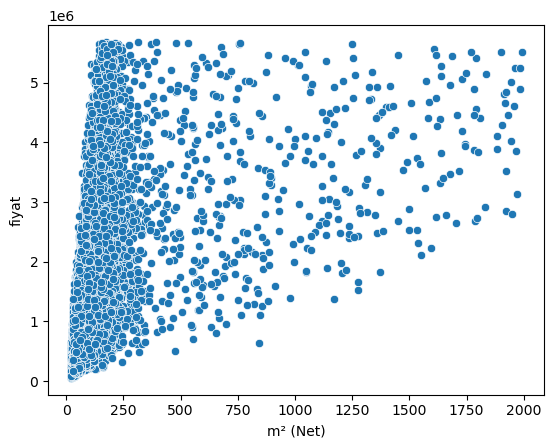

In [257]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatter plot ile fiyat ilişkisi
sns.scatterplot(data=veri_clean, x="m² (Net)", y="fiyat")  # target = fiyat
plt.show()

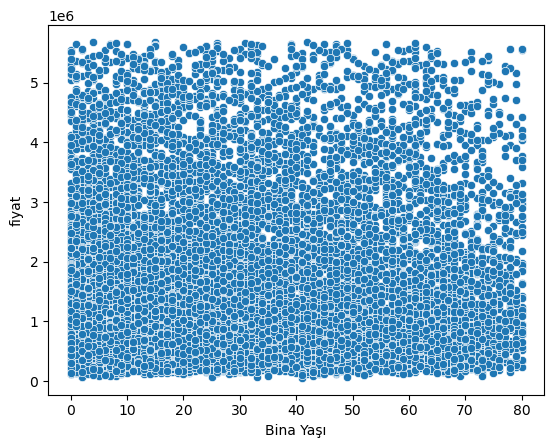

In [259]:
sns.scatterplot(data=veri_clean, x="Bina Yaşı", y="fiyat")  # target = fiyat
plt.show()

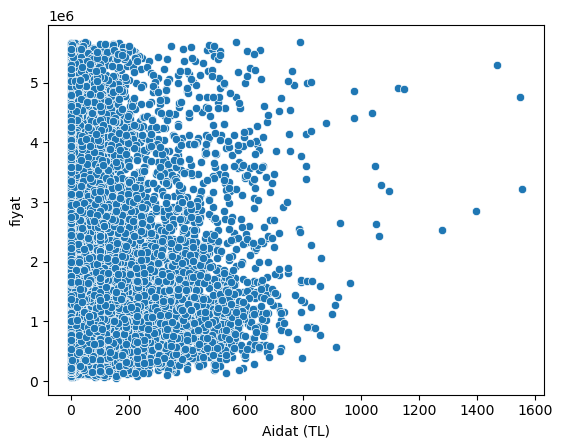

In [269]:
sns.scatterplot(data=veri_clean, x="Aidat (TL)", y="fiyat")  # target = fiyat
plt.show()

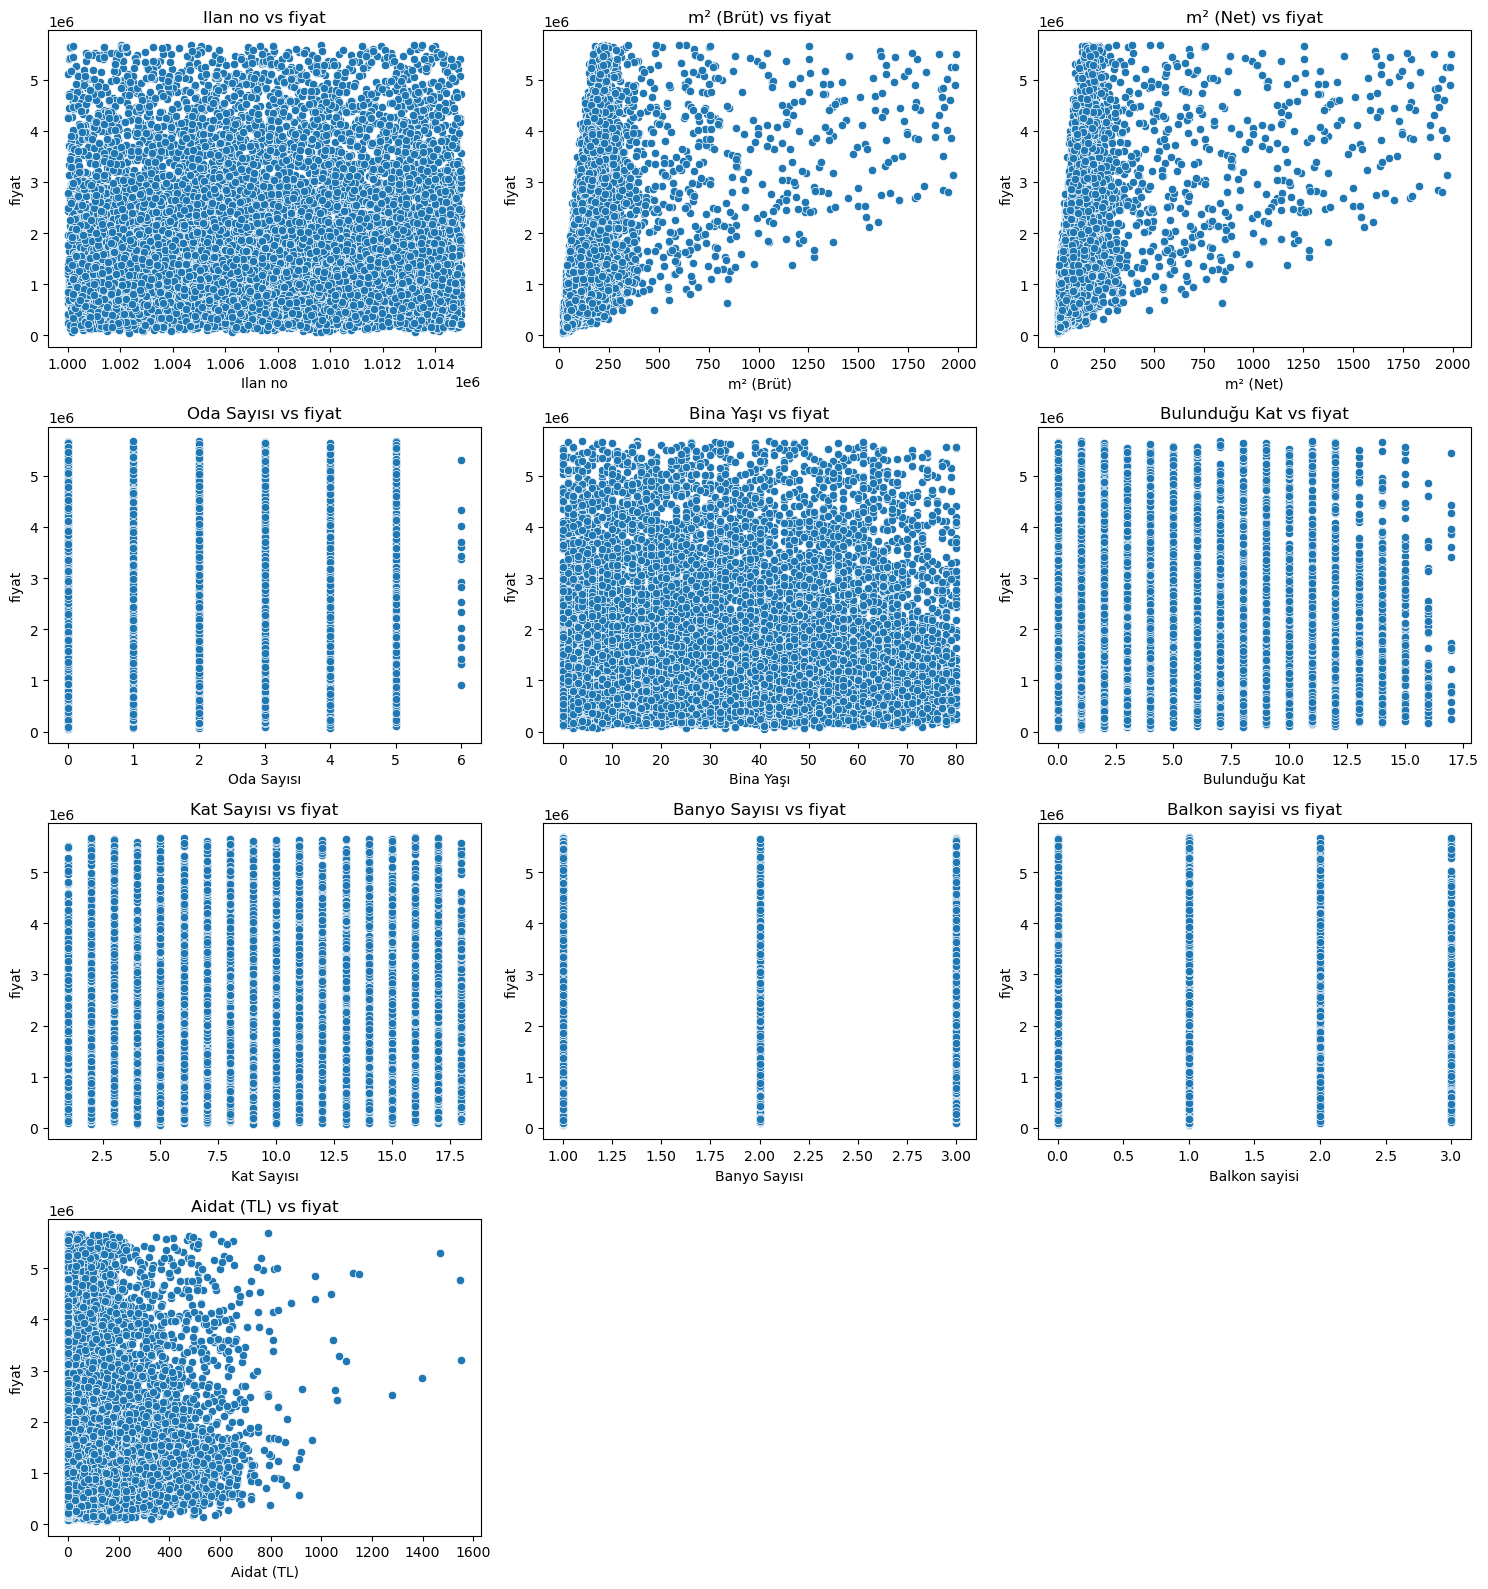

In [271]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sadece sayısal kolonları alıyoruz (target hariç)
numeric_cols = veri_clean.select_dtypes(include=['int64','float64']).columns.tolist()
numeric_cols.remove("fiyat")  # hedef kolon

# Kaç plot olacak
n_cols = 3  # satır başına 3 plot
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols  # toplam satır sayısı

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.scatterplot(data=veri_clean, x=col, y="fiyat", ax=axes[i])
    axes[i].set_title(f"{col} vs fiyat")

# Kalan boş subplotları sil
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
